# **Market Risk Validation Framework | Historical, Monte Carlo & Parametric VaR Modeling**

Python-based Market Risk Validation Framework for a multi-asset portfolio, implementing Historical, Parametric, and Monte Carlo VaR, Expected Shortfall, correlation analysis, VaR backtesting with Kupiec test, and stress testing to evaluate portfolio tail-risk and model reliability.



In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tickers = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "TCS.NS",
    "GOLDBEES.NS",
    "NIFTYBEES.NS"
]

start_date = "2020-01-01"
end_date = "2026-01-01"

In [4]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date
)["Close"]

/tmp/ipykernel_1655/1090801615.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  5 of 5 completed


In [5]:

print(data.isnull().sum())

Ticker
GOLDBEES.NS     1
HDFCBANK.NS     0
NIFTYBEES.NS    1
RELIANCE.NS     0
TCS.NS          0
dtype: int64


In [8]:
data = data.dropna()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1486 entries, 2020-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GOLDBEES.NS   1486 non-null   float64
 1   HDFCBANK.NS   1486 non-null   float64
 2   NIFTYBEES.NS  1486 non-null   float64
 3   RELIANCE.NS   1486 non-null   float64
 4   TCS.NS        1486 non-null   float64
dtypes: float64(5)
memory usage: 69.7 KB


In [10]:
print(data.isnull().sum())

Ticker
GOLDBEES.NS     0
HDFCBANK.NS     0
NIFTYBEES.NS    0
RELIANCE.NS     0
TCS.NS          0
dtype: int64


In [11]:
print(data.head())
print("\nShape of dataset:", data.shape)

Ticker      GOLDBEES.NS  HDFCBANK.NS  NIFTYBEES.NS  RELIANCE.NS       TCS.NS
Date                                                                        
2020-01-01    34.349998   605.529358    129.419998   675.324219  1841.150146
2020-01-02    34.349998   609.389160    130.139999   686.821228  1832.698364
2020-01-03    35.400002   600.698792    129.710007   687.648865  1869.222046
2020-01-06    36.150002   587.698730    127.370003   671.700684  1869.052246
2020-01-07    35.500000   597.004761    127.760002   682.034546  1873.639160

Shape of dataset: (1486, 5)


In [12]:
data.to_csv("portfolio_prices.csv")

In [13]:
returns = data.pct_change()

In [16]:
#First row
returns.isnull().sum()

,0
Ticker,
GOLDBEES.NS,0
HDFCBANK.NS,0
NIFTYBEES.NS,0
RELIANCE.NS,0
TCS.NS,0


In [15]:
returns = returns.dropna()

In [17]:
returns.isnull().sum()

,0
Ticker,
GOLDBEES.NS,0
HDFCBANK.NS,0
NIFTYBEES.NS,0
RELIANCE.NS,0
TCS.NS,0


All assets generated positive average daily returns over the sample period though the returns remain small relative to their volatility. Reliance and HDFC Bank exhibit the highest standard deviations, suggesting greater market risk exposure, while GoldBeES demonstrates comparatively lower volatility and smaller downside movements. The large negative minimum returns across equities also indicate the presence of tail-risk events and periods of market stress, implying that return distributions may deviate from normality.


In [18]:
returns.describe()

Ticker,GOLDBEES.NS,HDFCBANK.NS,NIFTYBEES.NS,RELIANCE.NS,TCS.NS
count,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000
mean,0.000828,0.000463,0.000607,0.000727,0.000464
std,0.009277,0.016174,0.010101,0.017818,0.014974
min,-0.040367,-0.126069,-0.101646,-0.131539,-0.094104
25%,-0.003670,-0.007126,-0.003740,-0.008398,-0.006862
50%,0.000671,0.000582,0.000831,0.000722,0.000068
75%,0.005313,0.007641,0.005788,0.008515,0.007745
max,0.047800,0.115996,0.067213,0.147180,0.098451


In [19]:
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])

portfolio_returns = returns.dot(weights)

portfolio_returns.head()

,0
Date,
2020-01-02,0.004571
2020-01-03,0.006586
2020-01-06,-0.007214
2020-01-07,0.002752
2020-01-08,0.005491


The portfolio return series exhibits a positive average daily return of 0.062%, accompanied by a standard deviation of 0.91%, indicating moderate overall portfolio volatility. The minimum daily return of -8.98% reflects the presence of significant downside risk during stressed market conditions, while the maximum return of 7.33% highlights periods of strong positive market movement. The distribution also shows that extreme losses are substantially larger than the average daily return, emphasizing the importance of downside risk measurement through Value at Risk (VaR) and stress-testing techniques.


In [20]:
portfolio_returns.describe()

,0
count,1485.000000
mean,0.000623
std,0.009056
min,-0.089785
25%,-0.003791
50%,0.000599
75%,0.005203
max,0.073262


The estimated 99% Historical Value at Risk (VaR) for the portfolio is -2.41%, implying that under normal market conditions, there is only a 1% probability that the portfolio will experience a daily loss greater than 2.41%. This indicates the presence of meaningful downside risk and highlights the importance of tail-risk measurement in portfolio risk management.

In [21]:
historical_var_99 = np.percentile(portfolio_returns, 1)

print("Historical VaR (99%):", historical_var_99)

Historical VaR (99%): -0.024117804208929276


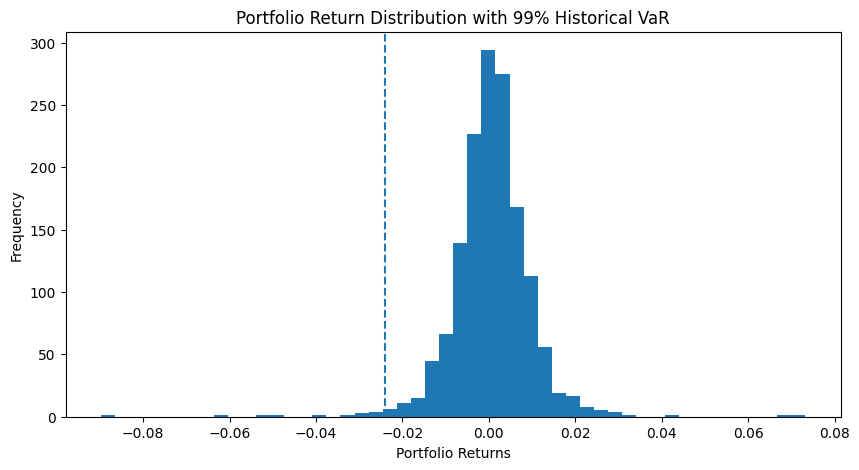

In [22]:
plt.figure(figsize=(10,5))

plt.hist(portfolio_returns, bins=50)

plt.axvline(
    historical_var_99,
    linestyle='dashed'
)

plt.title("Portfolio Return Distribution with 99% Historical VaR")
plt.xlabel("Portfolio Returns")
plt.ylabel("Frequency")

plt.show()

The mean return vector indicates that all assets generated positive average daily returns during the sample period, with GoldBeES and Reliance exhibiting comparatively higher average returns. The covariance matrix highlights strong positive co-movement among equity-based assets such as HDFC Bank, Reliance, TCS, and NIFTYBEES, suggesting that these assets tend to move together during market fluctuations. In contrast, GoldBeES shows very low covariance with the equity assets, indicating diversification benefits and lower correlation with broader market movements. The relatively higher variance observed for Reliance and HDFC Bank also reflects their greater contribution to overall portfolio volatility and market risk exposure.


In [23]:
mean_returns = returns.mean()

cov_matrix = returns.cov()

print(mean_returns)
print(cov_matrix)

Ticker
GOLDBEES.NS     0.000828
HDFCBANK.NS     0.000463
NIFTYBEES.NS    0.000607
RELIANCE.NS     0.000727
TCS.NS          0.000464
dtype: float64
Ticker         GOLDBEES.NS  HDFCBANK.NS  NIFTYBEES.NS  RELIANCE.NS    TCS.NS
Ticker                                                                      
GOLDBEES.NS   8.606345e-05    -0.000005  1.693279e-07     0.000003  0.000005
HDFCBANK.NS  -5.271321e-06     0.000262  1.184407e-04     0.000127  0.000073
NIFTYBEES.NS  1.693279e-07     0.000118  1.020202e-04     0.000125  0.000085
RELIANCE.NS   3.063888e-06     0.000127  1.253777e-04     0.000317  0.000101
TCS.NS        5.274912e-06     0.000073  8.531624e-05     0.000101  0.000224


In [24]:
num_simulations = 10000

simulated_returns = np.random.multivariate_normal(
    mean_returns,
    cov_matrix,
    num_simulations
)

In [25]:
portfolio_simulations = simulated_returns.dot(weights)

In [26]:
portfolio_simulations[:10]

array([ 0.0109012 , -0.01802692, -0.0032233 ,  0.01222111, -0.00314959,
        0.00187436,  0.01150124, -0.01713535, -0.01788222, -0.01210417])

In [27]:
mc_var_99 = np.percentile(portfolio_simulations, 1)

print("Monte Carlo VaR (99%):", mc_var_99)

Monte Carlo VaR (99%): -0.020252375755512784


The estimated 99% Monte Carlo VaR for the portfolio is -2.03%, compared to the Historical VaR estimate of -2.41%. The lower Monte Carlo VaR suggests that the simulated return distribution, based on multivariate normal assumptions, predicts less severe downside losses relative to historically observed market movements. This difference indicates that historical data may contain extreme tail-risk events and non-normal market behavior that are not fully captured under normality assumptions used in Monte Carlo simulation.



In [28]:
print("Historical VaR (99%):", historical_var_99)
print("Monte Carlo VaR (99%):", mc_var_99)

Historical VaR (99%): -0.024117804208929276
Monte Carlo VaR (99%): -0.020252375755512784


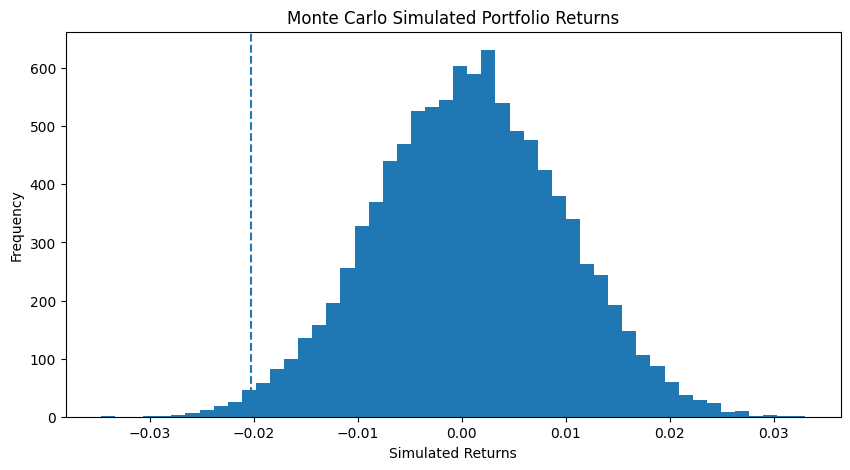

In [29]:
plt.figure(figsize=(10,5))

plt.hist(portfolio_simulations, bins=50)

plt.axvline(
    mc_var_99,
    linestyle='dashed'
)

plt.title("Monte Carlo Simulated Portfolio Returns")
plt.xlabel("Simulated Returns")
plt.ylabel("Frequency")

plt.show()

The Historical Simulation VaR estimate is larger in magnitude than the Monte Carlo VaR estimate, indicating that empirical returns exhibit heavier tails and more extreme downside realizations than those generated under the simulation assumptions. This suggests that the Monte Carlo framework may underestimate tail risk when return distributions deviate from normality.

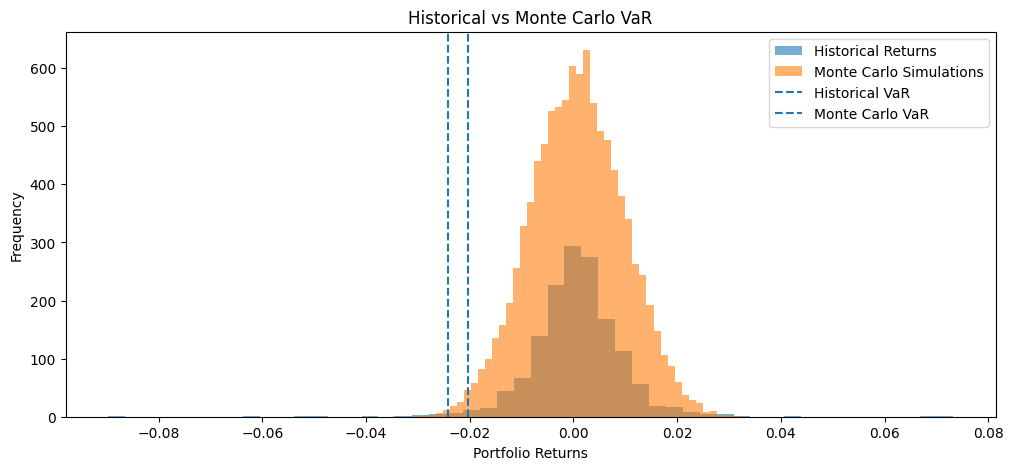

In [30]:
plt.figure(figsize=(12,5))

plt.hist(
    portfolio_returns,
    bins=50,
    alpha=0.6,
    label="Historical Returns"
)

plt.hist(
    portfolio_simulations,
    bins=50,
    alpha=0.6,
    label="Monte Carlo Simulations"
)

plt.axvline(
    historical_var_99,
    linestyle='dashed',
    label='Historical VaR'
)

plt.axvline(
    mc_var_99,
    linestyle='dashed',
    label='Monte Carlo VaR'
)

plt.title("Historical vs Monte Carlo VaR")
plt.xlabel("Portfolio Returns")
plt.ylabel("Frequency")

plt.legend()

plt.show()

Although both the Monte Carlo and Parametric VaR approaches rely on normality assumptions in the current implementation, the methodologies differ in estimation procedure. Parametric VaR derives risk analytically using the portfolio mean and standard deviation, whereas Monte Carlo VaR estimates downside risk numerically through simulated return paths generated from the multivariate return distribution. Minor differences between the two estimates arise from simulation variability and numerical approximation. The Monte Carlo framework, however, provides greater flexibility for extending the model to non-normal and more complex return dynamics in advanced risk modeling applications.


In [31]:
portfolio_mean = portfolio_returns.mean()

portfolio_std = portfolio_returns.std()

print("Portfolio Mean:", portfolio_mean)
print("Portfolio Std Dev:", portfolio_std)

Portfolio Mean: 0.0006227513482399357
Portfolio Std Dev: 0.009056166084686368


In [32]:
from scipy.stats import norm

In [33]:
z_score = norm.ppf(0.01)

print("Z-Score:", z_score)

Z-Score: -2.3263478740408408


In [34]:
parametric_var_99 = portfolio_mean + z_score * portfolio_std

print("Parametric VaR (99%):", parametric_var_99)

Parametric VaR (99%): -0.02044504136983096


The 99% Parametric VaR estimate for the portfolio is -2.04%, which is relatively close to the Monte Carlo VaR estimate of -2.03%, as both approaches rely on normality assumptions for return distributions. However, the Historical VaR estimate of -2.41% is noticeably more conservative, indicating that historically observed market data contains more severe downside events than those implied under normal distribution assumptions. This suggests the presence of fat tails and extreme market movements that are not fully captured by Gaussian-based risk models. Consequently, Historical VaR may provide a more realistic assessment of tail-risk exposure during stressed market conditions.


In [35]:
print("Historical VaR (99%):", historical_var_99)
print("Monte Carlo VaR (99%):", mc_var_99)
print("Parametric VaR (99%):", parametric_var_99)

Historical VaR (99%): -0.024117804208929276
Monte Carlo VaR (99%): -0.020252375755512784
Parametric VaR (99%): -0.02044504136983096


The correlation matrix indicates strong positive relationships among the equity-oriented assets, particularly between HDFCBANK and NIFTYBEES (0.73) as well as RELIANCE and NIFTYBEES (0.70), suggesting that these assets tend to move together during market fluctuations. Such high correlations reduce diversification benefits and may amplify portfolio losses during stressed market conditions. In contrast, GoldBeES exhibits near-zero or slightly negative correlations with the equity assets, indicating its potential role as a diversification instrument and partial hedge against broader equity market risk. Overall, the correlation structure highlights the concentration of systematic risk within the equity components of the portfolio.


In [36]:
correlation_matrix = returns.corr()

print(correlation_matrix)

Ticker        GOLDBEES.NS  HDFCBANK.NS  NIFTYBEES.NS  RELIANCE.NS    TCS.NS
Ticker                                                                     
GOLDBEES.NS      1.000000    -0.035131      0.001807     0.018535  0.037972
HDFCBANK.NS     -0.035131     1.000000      0.725002     0.440268  0.300794
NIFTYBEES.NS     0.001807     0.725002      1.000000     0.696648  0.564087
RELIANCE.NS      0.018535     0.440268      0.696648     1.000000  0.380363
TCS.NS           0.037972     0.300794      0.564087     0.380363  1.000000


The estimated 99% Expected Shortfall (ES) for the portfolio is -3.76%, indicating that conditional on losses exceeding the 99% VaR threshold, the portfolio is expected to incur an average daily loss of approximately 3.76%. Since the Expected Shortfall estimate is substantially larger in magnitude than the corresponding VaR estimate, it highlights the presence of severe tail-risk exposure and extreme downside events within the return distribution. Unlike VaR, which only identifies the loss threshold, Expected Shortfall provides additional insight into the severity of losses during stressed market conditions, making it a more informative measure of tail-risk.


In [37]:
expected_shortfall = portfolio_returns[
    portfolio_returns < historical_var_99
].mean()

print("Expected Shortfall (99%):", expected_shortfall)

Expected Shortfall (99%): -0.037639118477545


In [38]:
print("Historical VaR (99%):", historical_var_99)
print("Expected Shortfall (99%):", expected_shortfall)

Historical VaR (99%): -0.024117804208929276
Expected Shortfall (99%): -0.037639118477545


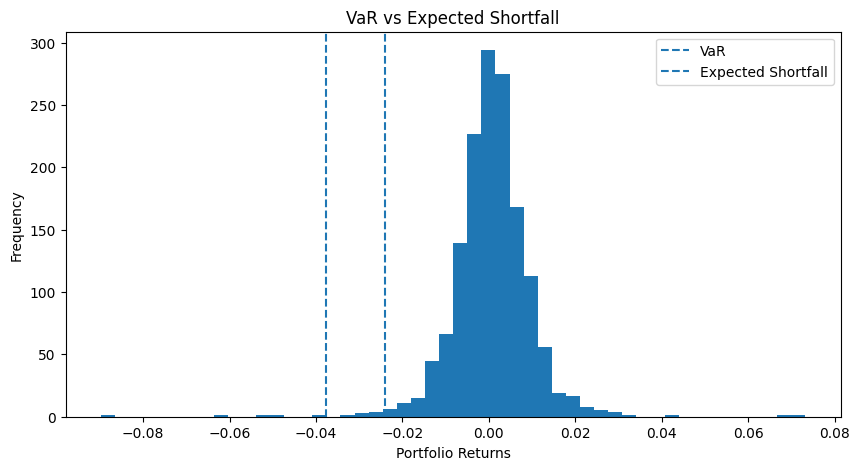

In [39]:
plt.figure(figsize=(10,5))

plt.hist(portfolio_returns, bins=50)

plt.axvline(
    historical_var_99,
    linestyle='dashed',
    label='VaR'
)

plt.axvline(
    expected_shortfall,
    linestyle='dashed',
    label='Expected Shortfall'
)

plt.title("VaR vs Expected Shortfall")
plt.xlabel("Portfolio Returns")
plt.ylabel("Frequency")

plt.legend()

plt.show()

VaR backtesting evaluates the effectiveness of the Historical VaR model by comparing predicted risk thresholds against actual portfolio losses. Under a 99% confidence framework, VaR breaches are expected to occur approximately 1% of the time. The observed breach frequency provides insight into model calibration and the adequacy of downside risk estimation. A materially higher breach rate would indicate that the model underestimates tail-risk exposure, whereas a lower breach rate may suggest overly conservative risk estimation.


In [40]:
breaches = portfolio_returns < historical_var_99

In [41]:
breaches.head()

,0
Date,
2020-01-02,False
2020-01-03,False
2020-01-06,False
2020-01-07,False
2020-01-08,False


In [42]:
num_breaches = breaches.sum()

total_observations = len(portfolio_returns)

breach_ratio = num_breaches / total_observations

print("Number of Breaches:", num_breaches)
print("Breach Ratio:", breach_ratio)

Number of Breaches: 15
Breach Ratio: 0.010101010101010102


The VaR backtesting results indicate 15 observed breaches over 1,485 trading days, corresponding to a breach ratio of 1.01%, which is extremely close to the theoretically expected 1% breach frequency under the 99% VaR framework. This suggests that the Historical VaR model is reasonably well calibrated and provides an accurate representation of portfolio downside risk over the sample period.

In [43]:
expected_breaches = total_observations * 0.01

print("Expected Breaches:", expected_breaches)
print("Actual Breaches:", num_breaches)

Expected Breaches: 14.85
Actual Breaches: 15


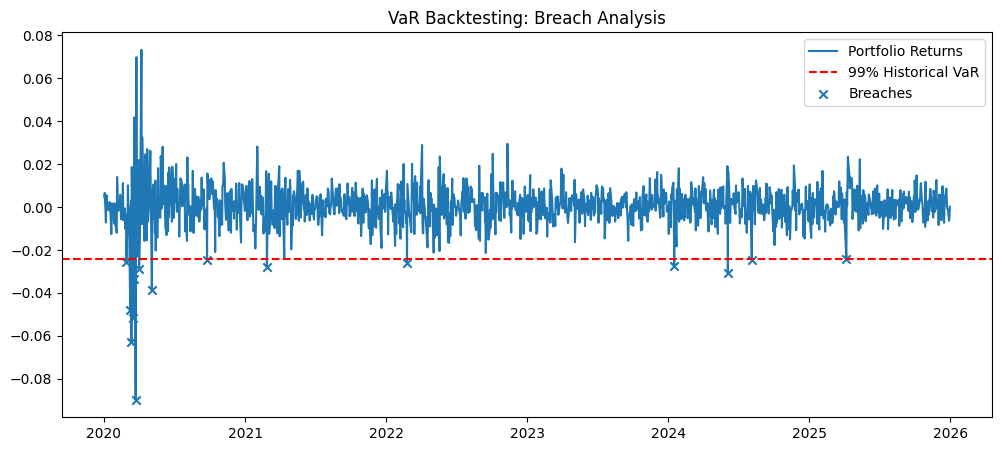

In [44]:
plt.figure(figsize=(12,5))

plt.plot(portfolio_returns, label='Portfolio Returns')

plt.axhline(
    historical_var_99,
    color='red',
    linestyle='dashed',
    label='99% Historical VaR'
)

plt.scatter(
    portfolio_returns.index[breaches],
    portfolio_returns[breaches],
    marker='x',
    label='Breaches'
)

plt.title("VaR Backtesting: Breach Analysis")

plt.legend()

plt.show()

In [45]:
from scipy.stats import chi2

The Kupiec Proportion of Failures (POF) test is applied to evaluate whether the observed VaR breach frequency is statistically consistent with the expected 1% failure rate under the 99% VaR framework. The extremely small likelihood ratio test statistic indicates minimal deviation between expected and observed exceptions. Consequently, the model does not exhibit evidence of systematic underestimation or overestimation of portfolio risk, suggesting that the Historical VaR model demonstrates adequate unconditional coverage and satisfactory calibration over the sample period.


In [46]:
x = num_breaches
n = total_observations
p = 0.01

In [47]:
p_hat = x / n

kupiec_stat = -2 * np.log(
    ((1 - p)**(n - x) * (p**x)) /
    ((1 - p_hat)**(n - x) * (p_hat**x))
)

print("Kupiec Test Statistic:", kupiec_stat)

Kupiec Test Statistic: 0.0015253806865040032


The Kupiec Proportion of Failures (POF) test produced a p-value of 0.969, which is substantially higher than the conventional 5% significance level. Therefore, the null hypothesis that the observed breach frequency is consistent with the expected 1% VaR exception rate cannot be rejected. This indicates that the Historical VaR model is well calibrated and provides statistically reliable downside risk estimates for the portfolio over the sample period.

In [48]:
p_value = 1 - chi2.cdf(kupiec_stat, df=1)

print("P-Value:", p_value)

P-Value: 0.9688456436155144


In [50]:
stress_scenarios = {
    "Equity Market Crash": np.array([0.03, -0.20, -0.18, -0.22, -0.15]),

    "Interest Rate Shock": np.array([-0.02, -0.10, -0.08, -0.12, -0.07]),

    "Mild Market Correction": np.array([0.01, -0.05, -0.04, -0.06, -0.03]),

    "Flight to Safety": np.array([0.08, -0.15, -0.12, -0.18, -0.10])
}

The simulated Equity Market Crash scenario generated the largest portfolio decline of -13.40%, significantly exceeding the losses estimated through Historical VaR and Expected Shortfall measures. The Interest Rate Shock and Flight-to-Safety scenarios also produced considerable negative portfolio returns, indicating sensitivity to macro-financial disruptions and equity market stress. In contrast, the Mild Market Correction scenario resulted in relatively limited downside impact.


In [51]:
for scenario_name, scenario_returns in stress_scenarios.items():

    stressed_portfolio_return = weights.dot(scenario_returns)

    print(
        f"{scenario_name}: "
        f"{stressed_portfolio_return:.2%}"
    )

Equity Market Crash: -13.40%
Interest Rate Shock: -7.45%
Mild Market Correction: -3.15%
Flight to Safety: -8.35%
